# 2. Preparación de Datos (Preprocessing)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ds_salaries.csv')
print('Shape original:', df.shape)
df.head()

Shape original: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [2]:
# Columnas a eliminar:
# - 'salary' y 'salary_currency': redundante con salary_in_usd (ya está en USD)
# - 'employee_residence': alta correlación con company_location, generaría ruido

COLS_DROP = ['salary', 'salary_currency', 'employee_residence']
df = df.drop(columns=COLS_DROP)
print('Columnas restantes:', df.columns.tolist())
print('Shape:', df.shape)

Columnas restantes: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'remote_ratio', 'company_location', 'company_size']
Shape: (3755, 8)


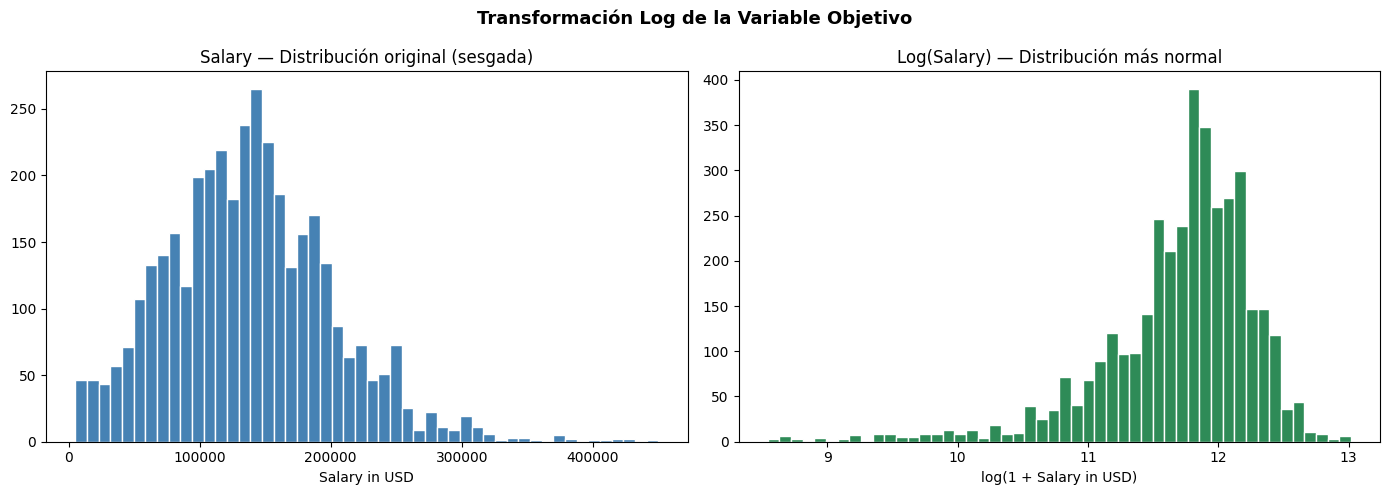

NOTA: Usaremos salary_log como target. Al predecir, aplicar np.expm1() para revertir.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary_in_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Salary — Distribución original (sesgada)')
axes[0].set_xlabel('Salary in USD')

df['salary_log'] = np.log1p(df['salary_in_usd'])
axes[1].hist(df['salary_log'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Log(Salary) — Distribución más normal')
axes[1].set_xlabel('log(1 + Salary in USD)')

plt.suptitle('Transformación Log de la Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/prep_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print('NOTA: Usaremos salary_log como target. Al predecir, aplicar np.expm1() para revertir.')

In [4]:
# Agrupar job_titles poco frecuentes como 'Other' para reducir cardinalidad
top_jobs = df['job_title'].value_counts()
top_jobs_list = top_jobs[top_jobs >= 10].index.tolist()
df['job_title_grouped'] = df['job_title'].apply(
    lambda x: x if x in top_jobs_list else 'Other'
)

# Agrupar países poco frecuentes
top_countries = df['company_location'].value_counts()
top_countries_list = top_countries[top_countries >= 10].index.tolist()
df['company_location_grouped'] = df['company_location'].apply(
    lambda x: x if x in top_countries_list else 'Other'
)

print('Job titles originales:', df['job_title'].nunique())
print('Job titles agrupados:', df['job_title_grouped'].nunique())
print('Países originales:', df['company_location'].nunique())
print('Países agrupados:', df['company_location_grouped'].nunique())

Job titles originales: 93
Job titles agrupados: 32
Países originales: 72
Países agrupados: 14


In [5]:
# Features de entrada
FEATURES = [
    'work_year',
    'experience_level',   # ordinal: EN < MI < SE < EX
    'employment_type',    # nominal: FT, PT, CT, FL
    'job_title_grouped',  # nominal (agrupado)
    'company_location_grouped',  # nominal (agrupado)
    'remote_ratio',       # numérica: 0, 50, 100
    'company_size',       # ordinal: S < M < L
]

TARGET = 'salary_log'  # regresión con log-transform

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (3004, 7) | Test: (751, 7)


In [6]:
# Variables numéricas
num_features = ['work_year', 'remote_ratio']

# Variables ordinales (con orden definido)
ord_exp = ['experience_level']
ord_exp_categories = [['EN', 'MI', 'SE', 'EX']]

ord_size = ['company_size']
ord_size_categories = [['S', 'M', 'L']]

# Variables nominales (sin orden)
nom_features = ['employment_type', 'job_title_grouped', 'company_location_grouped']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('ord_exp', OrdinalEncoder(categories=ord_exp_categories), ord_exp),
    ('ord_size', OrdinalEncoder(categories=ord_size_categories), ord_size),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_features),
], remainder='drop')

# Fit solo con train — NUNCA con test
preprocessor.fit(X_train)

X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print('Shape tras preprocesamiento:')
print(f'  X_train: {X_train_prep.shape}')
print(f'  X_test:  {X_test_prep.shape}')

Shape tras preprocesamiento:
  X_train: (3004, 54)
  X_test:  (751, 54)


In [7]:
# Convertir a object para el splti raw
X_train_save = X_train.copy()
X_test_save  = X_test.copy()
for col in X_train_save.select_dtypes(include='string').columns:
    X_train_save[col] = X_train_save[col].astype('object')
    X_test_save[col]  = X_test_save[col].astype('object')

In [8]:
# Guardar splits y preprocesador
joblib.dump(preprocessor, 'PKL_datos/preprocessor.pkl')
joblib.dump((X_train_save, X_test_save, y_train, y_test), 'PKL_datos/splits_raw.pkl')
joblib.dump((X_train_prep, X_test_prep, y_train, y_test), 'PKL_datos/splits_prep.pkl')

print('Guardado: preprocessor.pkl') #Pantilla de transofrmaciones de datos
print('Guardado: splits_raw.pkl (sin transformar — para el pipeline final)') #Datos originales solo con el split
print('Guardado: splits_prep.pkl (transformado — para el modelado)') #Datos transformados con el split para los modelos

Guardado: preprocessor.pkl
Guardado: splits_raw.pkl (sin transformar — para el pipeline final)
Guardado: splits_prep.pkl (transformado — para el modelado)
